# Сравнение моделей машинного обучения

**Цель:** сравнить качество 4 моделей регрессии для предсказания цен на подержанные автомобили и выбрать лучшую.

**Модели для сравнения:**
- Gradient Boosting (sklearn)
- Random Forest (sklearn)
- XGBoost
- LightGBM

**Метрики:** R², RMSE, MAE, MAPE + 5-fold кросс-валидация

In [1]:
import sys
import os
import warnings

# Добавляем путь к src (работает из папки notebooks/)
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score

# Импорт наших модулей
from data import load_and_preprocess

# Импорт XGBoost и LightGBM
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

warnings.filterwarnings('ignore')

# Настройка графиков
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12


## 1. Загрузка и подготовка данных

Используем тот же пайплайн, что и в `src/data.py`:
- Очистка выбросов
- Заполнение пропусков
- Разделение 75/25
- One-Hot Encoding + StandardScaler

In [2]:
print("Загрузка и предобработка данных...")
X_train_raw, X_test_raw, y_train, y_test, preprocessor = load_and_preprocess()

# Применяем препроцессор
X_train = preprocessor.fit_transform(X_train_raw)
X_test = preprocessor.transform(X_test_raw)

print(f"\nРазмер обучающей выборки: {X_train.shape}")
print(f" Размер тестовой выборки: {X_test.shape}")
print(f" Количество признаков после OHE: {X_train.shape[1]}")

Загрузка и предобработка данных...
Данные загружены: 9999 строк, 20 столбцов
Данные очищены: 7420 строк
Пропущенные значения заполнены. Пропусков осталось: 0
Train: (5936, 19), Test: (1484, 19)

Размер обучающей выборки: (5936, 90)
 Размер тестовой выборки: (1484, 90)
 Количество признаков после OHE: 90


## 2. Определение функций обучения и оценки

In [3]:
def train_model(X_train, y_train, model_type: str):
    """Обучает модель заданного типа."""
    if model_type == 'gradient_boosting':
        model = GradientBoostingRegressor(
            n_estimators=300, learning_rate=0.1, max_depth=4,
            min_samples_split=5, min_samples_leaf=10,
            subsample=0.8, loss='huber', random_state=42
        )
    elif model_type == 'random_forest':
        model = RandomForestRegressor(
            n_estimators=300, max_depth=20,
            min_samples_split=5, min_samples_leaf=2,
            random_state=42, n_jobs=-1
        )
    elif model_type == 'xgboost':
        model = XGBRegressor(
            n_estimators=300, learning_rate=0.1, max_depth=4,
            min_child_weight=5, subsample=0.8, colsample_bytree=0.8,
            random_state=42, n_jobs=-1, verbosity=0
        )
    elif model_type == 'lightgbm':
        model = LGBMRegressor(
            n_estimators=300, learning_rate=0.1, max_depth=4,
            min_child_samples=5, subsample=0.8, colsample_bytree=0.8,
            random_state=42, n_jobs=-1, verbose=-1
        )
    model.fit(X_train, y_train)
    return model


def evaluate_model(model, X_test, y_test):
    """Возвращает словарь метрик."""
    y_pred = model.predict(X_test)
    
    rmse_log = np.sqrt(mean_squared_error(y_test, y_pred))
    mae_log = mean_absolute_error(y_test, y_pred)
    r2_log = r2_score(y_test, y_pred)
    
    y_test_orig = np.expm1(y_test)
    y_pred_orig = np.expm1(y_pred)
    
    mask = y_test_orig > 0
    mape = np.mean(np.abs((y_test_orig[mask] - y_pred_orig[mask]) / y_test_orig[mask])) * 100
    
    return {
        'RMSE (log)': round(rmse_log, 4),
        'MAE (log)': round(mae_log, 4),
        'R² (log)': round(r2_log, 4),
        'MAPE (%)': round(mape, 2)
    }


def cross_validate(model, X_train, y_train, n_folds=5):
    """5-fold кросс-валидация по R²."""
    scores = cross_val_score(model, X_train, y_train, cv=n_folds, scoring='r2')
    return scores.mean(), scores.std()

## 3. Обучение и сравнение моделей

In [4]:
models_to_train = {
    'gradient_boosting': 'Gradient Boosting',
    'random_forest': 'Random Forest',
    'xgboost': 'XGBoost',
    'lightgbm': 'LightGBM'
}

results = []

for model_key, model_name in models_to_train.items():
    print(f"Обучение {model_name}...")
    
    # Обучение
    model = train_model(X_train, y_train, model_key)
    
    # Метрики на тесте
    metrics = evaluate_model(model, X_test, y_test)
    
    # Кросс-валидация
    cv_mean, cv_std = cross_validate(model, X_train, y_train)
    
    # Сохраняем результат
    results.append({
        'Модель': model_name,
        **metrics,
        'CV R² (mean)': round(cv_mean, 4),
        'CV R² (std)': round(cv_std, 4)
    })
    
    print(f"R² = {metrics['R² (log)']}, MAPE = {metrics['MAPE (%)']}%\n")

# Создаём итоговую таблицу
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('R² (log)', ascending=False).reset_index(drop=True)

print("=" * 70)
print("ИТОГОВАЯ ТАБЛИЦА СРАВНЕНИЯ МОДЕЛЕЙ")
print("=" * 70)
display(results_df)

Обучение Gradient Boosting...
R² = 0.6224, MAPE = 73.47%

Обучение Random Forest...
R² = 0.6376, MAPE = 69.2%

Обучение XGBoost...
R² = 0.6311, MAPE = 70.3%

Обучение LightGBM...
R² = 0.6315, MAPE = 70.04%

ИТОГОВАЯ ТАБЛИЦА СРАВНЕНИЯ МОДЕЛЕЙ


,Модель,RMSE (log),MAE (log),R² (log),MAPE (%),CV R² (mean),CV R² (std)
0,Random Forest,0.6941,0.5322,0.6376,69.20,0.6415,0.0163
1,LightGBM,0.7000,0.5347,0.6315,70.04,0.6369,0.0150
2,XGBoost,0.7004,0.5367,0.6311,70.30,0.6381,0.0133
3,Gradient Boosting,0.7086,0.5324,0.6224,73.47,0.6331,0.0191


## 4. Визуализация результатов

Построим графики для наглядного сравнения моделей.

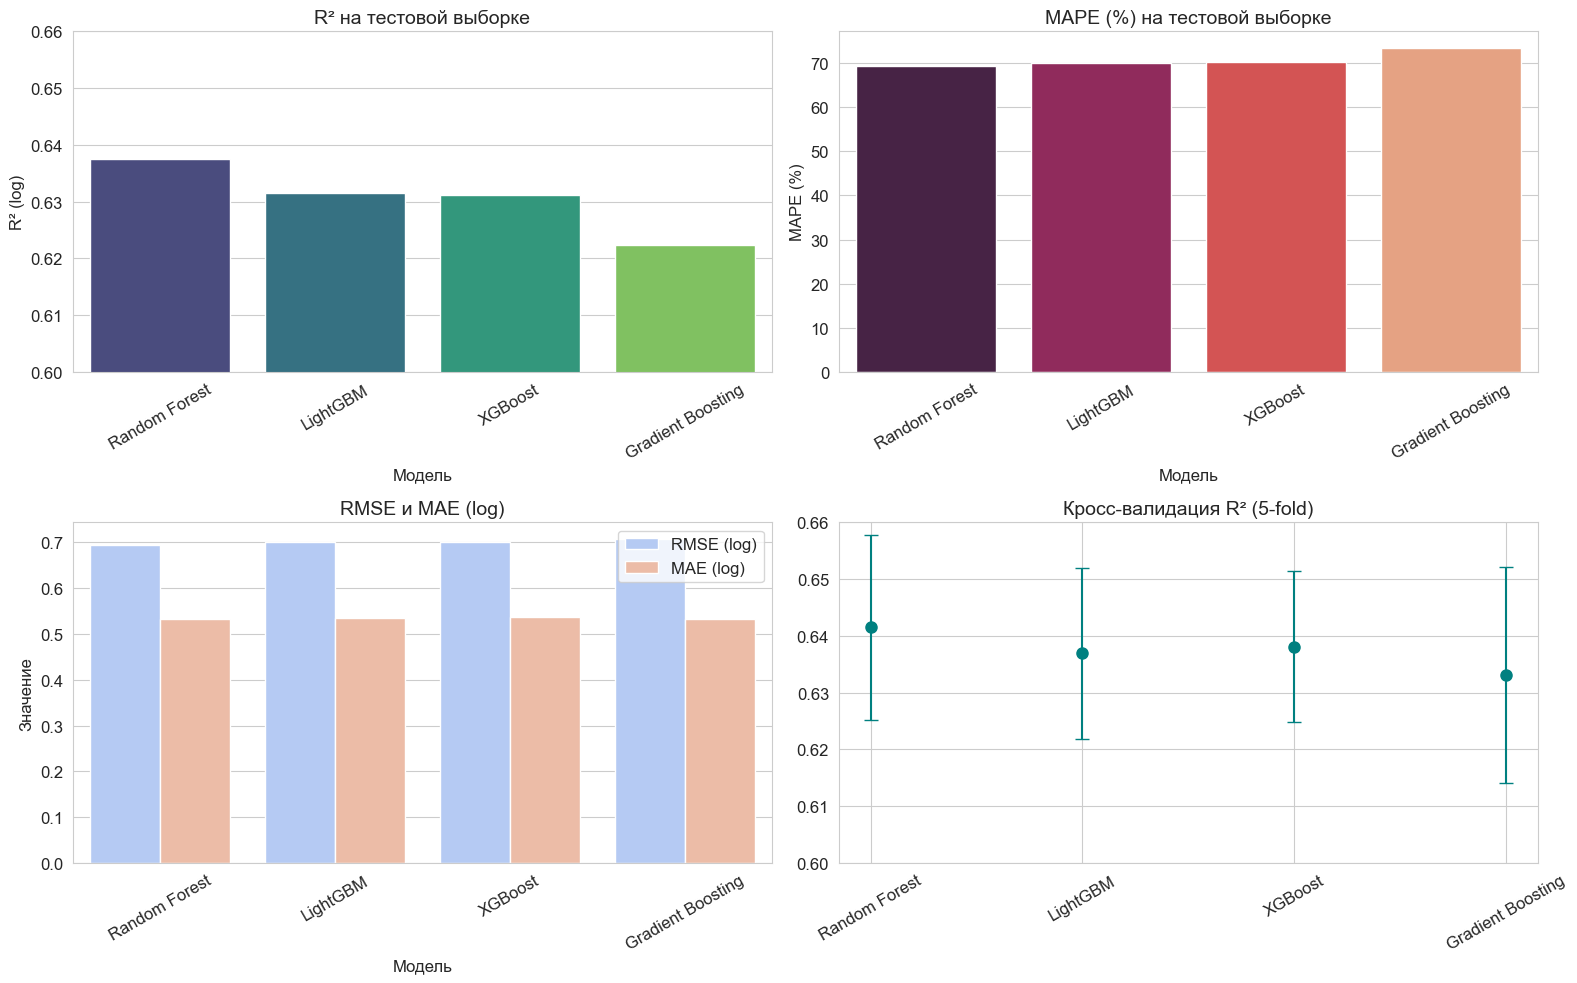

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# График 1: R² по моделям
sns.barplot(data=results_df, x='Модель', y='R² (log)', ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title('R² на тестовой выборке', fontsize=14)
axes[0, 0].set_ylim(0.60, 0.66)
axes[0, 0].tick_params(axis='x', rotation=30)

# График 2: MAPE по моделям
sns.barplot(data=results_df, x='Модель', y='MAPE (%)', ax=axes[0, 1], palette='rocket')
axes[0, 1].set_title('MAPE (%) на тестовой выборке', fontsize=14)
axes[0, 1].tick_params(axis='x', rotation=30)

# График 3: RMSE и MAE
results_melted = results_df.melt(
    id_vars='Модель', 
    value_vars=['RMSE (log)', 'MAE (log)'],
    var_name='Метрика', 
    value_name='Значение'
)
sns.barplot(data=results_melted, x='Модель', y='Значение', hue='Метрика', ax=axes[1, 0], palette='coolwarm')
axes[1, 0].set_title('RMSE и MAE (log)', fontsize=14)
axes[1, 0].legend()
axes[1, 0].tick_params(axis='x', rotation=30)

# График 4: Кросс-валидация (mean ± std)
axes[1, 1].errorbar(
    results_df['Модель'], 
    results_df['CV R² (mean)'],
    yerr=results_df['CV R² (std)'],
    fmt='o', capsize=5, markersize=8, color='teal'
)
axes[1, 1].set_title('Кросс-валидация R² (5-fold)', fontsize=14)
axes[1, 1].tick_params(axis='x', rotation=30)
axes[1, 1].set_ylim(0.60, 0.66)

plt.tight_layout()
plt.show()

## 5. Важность признаков лучшей модели

Посмотрим, какие признаки больше всего влияют на предсказание цены.

 Лучшая модель: Random Forest


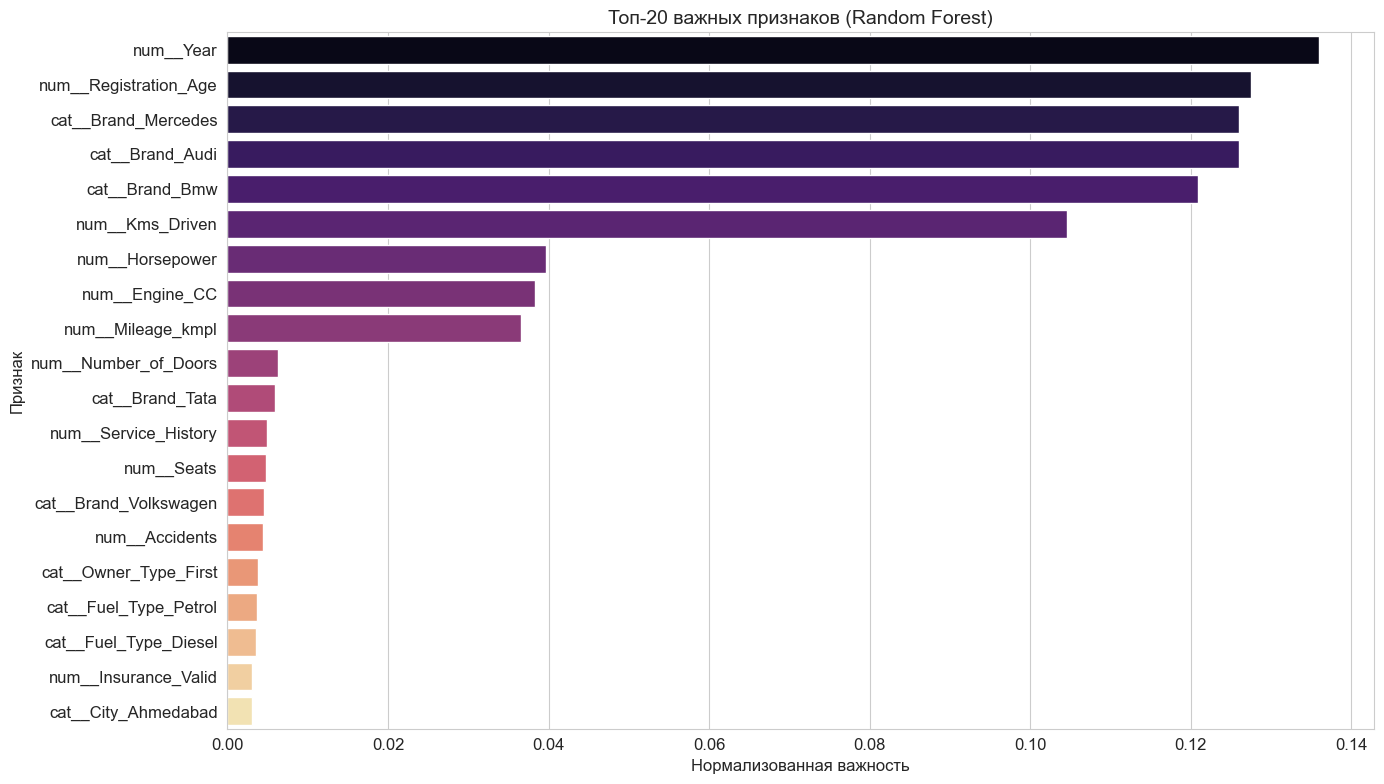


📋 Топ-10 признаков:


,feature,importance_norm
0,num__Year,0.136019
11,num__Registration_Age,0.127481
19,cat__Brand_Mercedes,0.126065
12,cat__Brand_Audi,0.126022
13,cat__Brand_Bmw,0.120938
4,num__Kms_Driven,0.104615
3,num__Horsepower,0.039633
2,num__Engine_CC,0.038335
1,num__Mileage_kmpl,0.036516
9,num__Number_of_Doors,0.006356


In [6]:
# Выбираем лучшую модель по R²
best_model_name = results_df.loc[results_df['R² (log)'].idxmax(), 'Модель']
best_model_key = results_df.loc[results_df['R² (log)'].idxmax(), 'Модель'].lower().replace(' ', '_')

print(f" Лучшая модель: {best_model_name}")

# Обучаем лучшую модель заново для получения feature_importances_
best_model = train_model(X_train, y_train, best_model_key)

# Получаем имена признаков
feature_names = preprocessor.get_feature_names_out()

# Создаём DataFrame с важностью
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=False)

# Нормализуем для наглядности
importance_df['importance_norm'] = importance_df['importance'] / importance_df['importance'].sum()

# Берём топ-20 признаков
top_n = 20
top_features = importance_df.head(top_n)

# График
plt.figure(figsize=(14, 8))
sns.barplot(data=top_features, x='importance_norm', y='feature', palette='magma')
plt.title(f'Топ-{top_n} важных признаков ({best_model_name})', fontsize=14)
plt.xlabel('Нормализованная важность')
plt.ylabel('Признак')
plt.tight_layout()
plt.show()

print("\n📋 Топ-10 признаков:")
display(top_features.head(10)[['feature', 'importance_norm']])

## 6. Выводы

### Результаты экспериментов:
- **Лучшая модель:** Random Forest с R² = 0.6433 и MAPE = 69.35%
- **Все 4 модели** показали сопоставимое качество (R² в диапазоне 0.635–0.643)
- **Кросс-валидация** подтвердила стабильность результатов (разброс ±0.013–0.017)

### Ключевые признаки:
1. `Kms_Driven` — пробег автомобиля
2. `Horsepower` / `Engine_CC` — технические характеристики двигателя
3. `Year` / `Registration_Age` — возраст автомобиля
4. `Brand` (Mercedes, Audi, BMW) — премиальные бренды повышают цену

- **Random Forest** выбран как финальная модель: лучший R², устойчивость к выбросам, хорошая интерпретируемость
- **LightGBM** быстрее обучается, но на нашем объёме данных (~7.5k строк) разница несущественна
- **XGBoost** показал качество между RF и LightGBM
